In [1]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re
import venn

In [2]:
sample=[1,1,2,2]
def remove_dul(tar_list=sample):
    res=[]
    [res.append(x) for x in tar_list if x not in res]
    return(res)
def procount(dir='D:\\yuming\\2023\\20230311\\csodiaq'):
    plasma_pro = []
    for file in os.listdir(dir):
        if file.endswith(".csv") and 'proteinFDR' in file:
            plasma_pro.append(os.path.join(dir, file))
    dic={}
    for i in range(len(plasma_pro)):
        df=pd.read_csv(plasma_pro[i]) 
        yummy=len(remove_dul(tar_list=df['protein'].tolist()))
        dic[str(plasma_pro[i].split('\\')[-1])]=yummy
        dfnew=pd.DataFrame.from_dict(dic, orient='index')
    return(dfnew)
def pepcount(dir='D:\\yuming\\2023\\20230311\\csodiaq'):
    plasma_pro = []
    for file in os.listdir(dir):
        if file.endswith(".csv") and 'proteinFDR' in file:
            plasma_pro.append(os.path.join(dir, file))
    dic={}
    for i in range(len(plasma_pro)):
        df=pd.read_csv(plasma_pro[i]) 
        yummy=len(remove_dul(tar_list=df['peptide'].tolist()))
        dic[str(plasma_pro[i].split('\\')[-1])]=yummy
        dfnew=pd.DataFrame.from_dict(dic, orient='index')
    return(dfnew)
def metcount(dir = "D:\\yuming\\2023\\20230311\\csodiaq"):
    meta_293T = []
   
    for file in os.listdir(dir):
        if file.endswith(".csv") and 'isos' in file:
            meta_293T.append(os.path.join(dir, file))
    dic={}
    for i in range(len(meta_293T)):
        df=pd.read_csv(meta_293T[i]) 
        yummy=len(df['mz'].tolist())
        #yummy=len(remove_dul(tar_list=df[df['scan_num']<125]['mz'].tolist()))
        dic[str(meta_293T[i].split('\\')[-1])]=yummy
        dfnew=pd.DataFrame.from_dict(dic, orient='index')  
    return(dfnew)

# compare the protein, peptides, detected metabolites in multiomic method and single ~~ome method,  ,sample: 293T

In [3]:
#  

In [4]:
procount(dir='D:\\yuming\\2023\\20230312\\quantification\\csodiaq')

,0
CsoDIAq-file1_MIX_1_1_corrected_proteinFDR.csv,1364
CsoDIAq-file2_MIX_1_2_corrected_proteinFDR.csv,1343
CsoDIAq-file3_MIX_1_3_corrected_proteinFDR.csv,1291
CsoDIAq-file4_MIX_3_1_corrected_proteinFDR.csv,1202
CsoDIAq-file5_MIX_3_2_corrected_proteinFDR.csv,1123
CsoDIAq-file6_MIX_3_3_corrected_proteinFDR.csv,1290
CsoDIAq-file7_MIX_4_1_corrected_proteinFDR.csv,1070
CsoDIAq-file8_MIX_4_2_corrected_proteinFDR.csv,1132
CsoDIAq-file9_MIX_4_3_corrected_proteinFDR.csv,1191
CsoDIAq-file10_MIX_5_1_corrected_proteinFDR.csv,990


In [5]:
metcount(dir='D:\\yuming\\2023\\20230312\\quantification\\meta_results')

,0
MIX_2_1_isos.csv,9142
MIX_2_2_isos.csv,9516
MIX_2_3_isos.csv,9572
MIX_3_1_isos.csv,9427
MIX_3_2_isos.csv,9577
MIX_3_3_isos.csv,9546
MIX_4_1_isos.csv,9785
MIX_4_2_isos.csv,9842
MIX_4_3_isos.csv,9956
MIX_5_1_isos.csv,10328


In [17]:
mix1_pro=[1364,1343,1291]
mix2_pro=[1202,1123,1290]
mix3_pro=[1070,1132,1191]
mix4_pro=[990,996,866]
mix5_pro=[834,727,731]

mix1_meta=[8974,9056,9250]
mix2_meta=[9427,9577,9546]
mix3_meta=[9785,9842,9956]
mix4_meta=[10328,10115,10150]
mix5_meta=[9794,9978,9413]





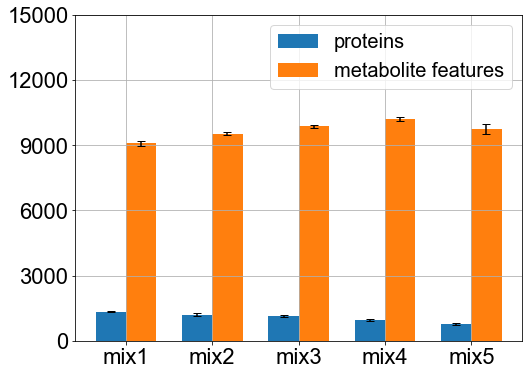

In [18]:
import matplotlib.pyplot as plt
import numpy as np
matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(8, 6))
# generate sample data
x = np.array(['mix1','mix2','mix3','mix4','mix5'])
y1 = np.array([np.mean(mix1_pro),np.mean(mix2_pro),np.mean(mix3_pro),np.mean(mix4_pro),np.mean(mix5_pro)])
y2 = np.array([np.mean(mix1_meta),np.mean(mix2_meta),np.mean(mix3_meta),np.mean(mix4_meta),np.mean(mix5_meta)])
y1_err = np.array([np.std(mix1_pro),np.std(mix2_pro),np.std(mix3_pro),np.std(mix4_pro),np.std(mix5_pro)])
y2_err = np.array([np.std(mix1_meta),np.std(mix2_meta),np.std(mix3_meta),np.std(mix4_meta),np.std(mix5_meta)])

# set width of bars
bar_width = 0.35

# set x-axis ticks
tick_pos = np.arange(len(x))

# create bar chart
plt.bar(tick_pos, y1, bar_width, label='proteins')
plt.bar(tick_pos + bar_width, y2, bar_width, label='metabolite features')
# add error bars
plt.errorbar(tick_pos, y1, yerr=y1_err, fmt='none', capsize=4, color='black')
plt.errorbar(tick_pos + bar_width, y2, yerr=y2_err, fmt='none', capsize=4, color='black')
# set labels, title, and legend
#plt.xlabel('X values')
#plt.ylabel('Y values')
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xticks(tick_pos + bar_width/2, x)
plt.yticks(range(0, 17000, 3000))
plt.legend(fontsize=20)
plt.grid()
# show chart
plt.show()

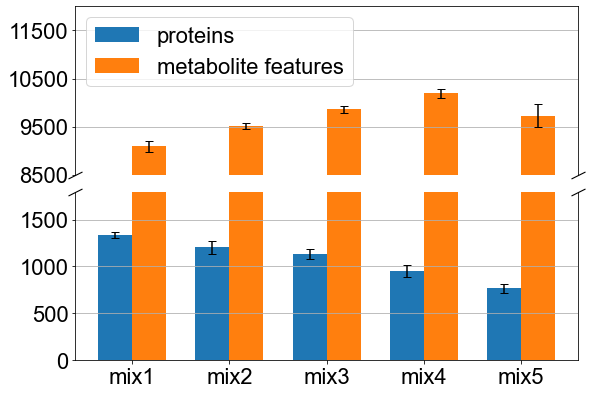

In [129]:

# create sample data
x = ['mix1','mix2','mix3','mix4','mix5']
y1 = np.array([np.mean(mix1_pro),np.mean(mix2_pro),np.mean(mix3_pro),np.mean(mix4_pro),np.mean(mix5_pro)])
y2 = np.array([np.mean(mix1_meta),np.mean(mix2_meta),np.mean(mix3_meta),np.mean(mix4_meta),np.mean(mix5_meta)])
y1_err = np.array([np.std(mix1_pro),np.std(mix2_pro),np.std(mix3_pro),np.std(mix4_pro),np.std(mix5_pro)])
y2_err = np.array([np.std(mix1_meta),np.std(mix2_meta),np.std(mix3_meta),np.std(mix4_meta),np.std(mix5_meta)])

# create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# set figure size
fig.set_size_inches(9, 6.5)

# set font size
plt.rcParams.update({'font.size': 12})

# set tick font size
ax1.tick_params(axis='both', which='major', labelsize=10)
ax2.tick_params(axis='both', which='major', labelsize=10)

# set font family
plt.rcParams['font.family'] = 'Arial'

# set bar width
bar_width = 0.35

# create tick positions
tick_pos = np.arange(len(x))

# plot bars with error bars on ax1
ax1.bar(tick_pos, y1, bar_width, yerr=y1_err, label='proteins', capsize=4)
ax1.bar(tick_pos + bar_width, y2, bar_width, yerr=y2_err, label='metabolite features', capsize=4)
ax1.set_ylim(8500, 12000)
ax1.legend(loc='upper left',fontsize=22)
ax1.tick_params(axis='both', which='major', labelsize=22)
ax1.xaxis.set_visible(False)
ax1.spines['bottom'].set_visible(False)

# plot bars with error bars on ax2
ax2.bar(tick_pos, y1, bar_width, yerr=y1_err, label='proteins', capsize=4)
ax2.bar(tick_pos + bar_width, y2, bar_width, yerr=y2_err, label='metabolite features', capsize=4)
ax2.set_ylim(0, 1800)
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.spines['top'].set_visible(False)
#ax2.legend(loc='upper left')

# center x labels
ax1.set_xticks(tick_pos + bar_width / 2)
ax1.set_xticklabels(x)
ax2.set_xticks(tick_pos + bar_width / 2)
ax2.set_xticklabels(x)

# add horizontal grid lines
ax1.yaxis.grid(True)
ax2.yaxis.grid(True)
ax1.set_yticks(np.arange(8500, 12000, 1000))
ax2.set_yticks(np.arange(0, 1800, 500))

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=14,
              linestyle="none", color='k', mec='k', mew=1.1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
# adjust spacing between subplots
fig.subplots_adjust(hspace=0.1)

plt.show()


In [10]:
procount(dir='D:\\yuming\\2023\\20230402\\csodiaq')

,0
CsoDIAq-file1_293T_mix1_corrected_proteinFDR.csv,1368
CsoDIAq-file2_293T_mix2_corrected_proteinFDR.csv,1322
CsoDIAq-file3_293T_mix3_corrected_proteinFDR.csv,1214
CsoDIAq-file4_293T_mix4_corrected_proteinFDR.csv,1199
CsoDIAq-file5_293T_pro_corrected_proteinFDR.csv,1322
CsoDIAq-file6_293T_pro1_corrected_proteinFDR.csv,1332
CsoDIAq-file7_293T_pro2_corrected_proteinFDR.csv,1327
CsoDIAq-file8_293T_pro3_corrected_proteinFDR.csv,1328


In [11]:
pepcount(dir='D:\\yuming\\2023\\20230402\\csodiaq')

,0
CsoDIAq-file1_293T_mix1_corrected_proteinFDR.csv,4032
CsoDIAq-file2_293T_mix2_corrected_proteinFDR.csv,3833
CsoDIAq-file3_293T_mix3_corrected_proteinFDR.csv,3437
CsoDIAq-file4_293T_mix4_corrected_proteinFDR.csv,3341
CsoDIAq-file5_293T_pro_corrected_proteinFDR.csv,3872
CsoDIAq-file6_293T_pro1_corrected_proteinFDR.csv,3931
CsoDIAq-file7_293T_pro2_corrected_proteinFDR.csv,3937
CsoDIAq-file8_293T_pro3_corrected_proteinFDR.csv,3767


In [12]:
procount(dir='D:\\yuming\\2023\\20230402\\csodiaq')

,0
CsoDIAq-file1_293T_mix1_corrected_proteinFDR.csv,1368
CsoDIAq-file2_293T_mix2_corrected_proteinFDR.csv,1322
CsoDIAq-file3_293T_mix3_corrected_proteinFDR.csv,1214
CsoDIAq-file4_293T_mix4_corrected_proteinFDR.csv,1199
CsoDIAq-file5_293T_pro_corrected_proteinFDR.csv,1322
CsoDIAq-file6_293T_pro1_corrected_proteinFDR.csv,1332
CsoDIAq-file7_293T_pro2_corrected_proteinFDR.csv,1327
CsoDIAq-file8_293T_pro3_corrected_proteinFDR.csv,1328


In [13]:
metcount(dir = "D:\\yuming\\2023\\20230402\\meta_results")

,0
293T_meta1_isos.csv,15945
293T_meta2_isos.csv,15030
293T_meta3_isos.csv,16058
293T_mix1_isos.csv,8509
293T_mix2_isos.csv,8358
293T_mix3_isos.csv,8308
293T_mix4_isos.csv,7788
293T_meta5_isos.csv,4816


In [112]:

mix_metabolome=[7788,8308,8358]
metabolome_only=[7972.5, 7915.0, 8229.0]

mix_proteins=[1368,1322,1291]
proteins_only=[1332,1327,1328]

mix_peptides=[4032,3833,3637]
peptides_only=[3931,3937,3767]



In [113]:
np.mean(mix_metabolome)

8151.333333333333

In [114]:
np.std(mix_metabolome)

257.7250904010361

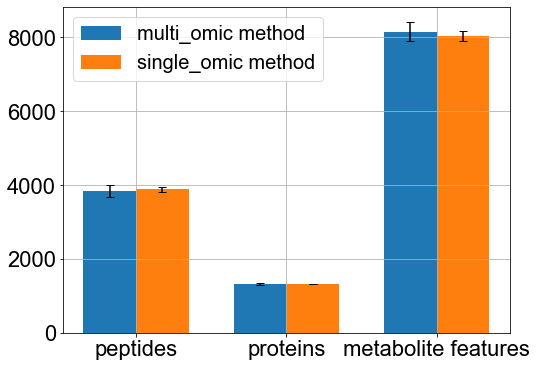

In [115]:
import matplotlib.pyplot as plt
import numpy as np
matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(8, 6))
# generate sample data
x = np.array(['peptides','proteins','metabolite features'])
y1 = np.array([np.mean(mix_peptides),np.mean(mix_proteins),np.mean(mix_metabolome)])
y2 = np.array([np.mean(peptides_only),np.mean(proteins_only),np.mean(metabolome_only)])
y1_err = np.array([np.std(mix_peptides),np.std(mix_proteins),np.std(mix_metabolome)])
y2_err = np.array([np.std(peptides_only),np.std(proteins_only),np.std(metabolome_only)])

# set width of bars
bar_width = 0.35

# set x-axis ticks
tick_pos = np.arange(len(x))

# create bar chart
plt.bar(tick_pos, y1, bar_width, label='multi_omic method')
plt.bar(tick_pos + bar_width, y2, bar_width, label='single_omic method')
# add error bars
plt.errorbar(tick_pos, y1, yerr=y1_err, fmt='none', capsize=4, color='black')
plt.errorbar(tick_pos + bar_width, y2, yerr=y2_err, fmt='none', capsize=4, color='black')
# set labels, title, and legend
#plt.xlabel('X values')
#plt.ylabel('Y values')
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xticks(tick_pos + bar_width/2, x)
plt.yticks(range(0, 9000, 2000))
plt.legend(fontsize=20)
plt.grid()
# show chart
plt.show()

# compare the protein, peptides, detected metabolites with different metabolome:proteome ratio,sample: 293T

In [100]:
pep=[1545,1513,1490.3,1443,1382,1298.6,1184,1065]

peperror=[48,31,27,27,40,26,23,30]

meta=[7837.3,7747,7862,7803,7875,7612,7877,7902]
metaerror=[50,47,93,108,74,168,120,140]
ratio=['1:10','1:5','1:3','1:2','1:1','2:1','3:1','5:1']

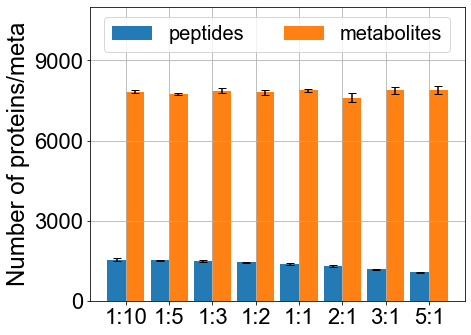

In [27]:
# protein identifications from different Compensation Voltage for Hela and T293 cells 
plt.figure(figsize=(8,6),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"

bar_width=0.43
plt.bar(x=range(len(pep)),height=pep,yerr=peperror,label='peptides',alpha=0.98,width=bar_width,capsize=4)
plt.bar(x=np.arange(len(meta))+bar_width,height=meta,yerr=metaerror,label='metabolites',alpha=0.98,width=bar_width,capsize=4)

plt.xticks(np.arange(len(ratio))+bar_width/2, ratio)
#plt.xlabel('Ratio',fontsize=24)
plt.ylabel('Number of proteins/meta',fontsize=24)
#plt.title('10 peptide quantities',fontsize=26)
plt.xticks(fontsize=22)
#plt.xticks(rotation=20)
plt.yticks(fontsize=22)
#plt.xticks(np.arange(0, 24, 4))
plt.yticks(np.arange(0,11000, 3000))
#plt.xlim(7.8,23)
plt.ylim(0,11000)
plt.legend(fontsize=20,loc='upper center', bbox_to_anchor=(0.5, 1.0),
          ncol=2)
plt.grid()
plt.subplots_adjust(left=0.25,bottom=0.2)
#plt.tight_layout()
#plt.legend(bbox_to_anchor=(1.02,1), borderaxespad=0,frameon=False)
#plt.savefig('D:\\Project 2 DIrect infusion shotgun proteome analysis\\robust and reproducibility\\CV analysis_protein.svg', dpi=600) 
plt.show()

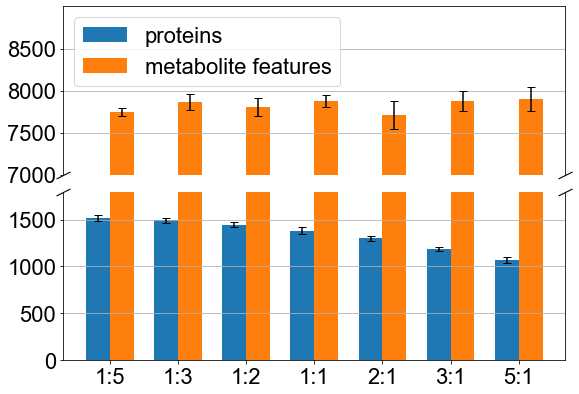

In [126]:
# create sample data
pep2=[1513,1490.3,1443,1382,1298.6,1184,1065]

pep_err2=[31,27,27,40,26,23,30]

meta2=[7747,7862,7803,7875,7712,7877,7902]
meta_err2=[47,93,108,74,168,120,140]
ratio2=['1:5','1:3','1:2','1:1','2:1','3:1','5:1']
# create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# set figure size
fig.set_size_inches(9, 6.5)

# set font size
plt.rcParams.update({'font.size': 12})

# set tick font size
ax1.tick_params(axis='both', which='major', labelsize=10)
ax2.tick_params(axis='both', which='major', labelsize=10)

# set font family
plt.rcParams['font.family'] = 'Arial'

# set bar width
bar_width = 0.35

# create tick positions
tick_pos = np.arange(len(ratio2))

# plot bars with error bars on ax1
ax1.bar(tick_pos, pep2, bar_width, yerr=pep_err2, label='proteins', capsize=4)
ax1.bar(tick_pos + bar_width, meta2, bar_width, yerr=meta_err2, label='metabolite features', capsize=4)
ax1.set_ylim(7000, 9000)
ax1.legend(loc='upper left',fontsize=22)
ax1.tick_params(axis='both', which='major', labelsize=22)
ax1.xaxis.set_visible(False)
ax1.spines['bottom'].set_visible(False)

# plot bars with error bars on ax2
ax2.bar(tick_pos, pep2, bar_width, yerr=pep_err2, label='proteins', capsize=4)
ax2.bar(tick_pos + bar_width, meta2, bar_width, yerr=meta_err2, label='metabolite features', capsize=4)
ax2.set_ylim(0, 1800)
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.spines['top'].set_visible(False)
#ax2.legend(loc='upper left')

# center x labels
ax1.set_xticks(tick_pos + bar_width / 2)
ax1.set_xticklabels(ratio2)
ax2.set_xticks(tick_pos + bar_width / 2)
ax2.set_xticklabels(ratio2)

# add horizontal grid lines
ax1.yaxis.grid(True)
ax2.yaxis.grid(True)
ax1.set_yticks(np.arange(7000, 9000, 500))
ax2.set_yticks(np.arange(0, 1800, 500))

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=14,
              linestyle="none", color='k', mec='k', mew=1.1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
# adjust spacing between subplots
fig.subplots_adjust(hspace=0.1)

plt.show()


# compare the protein, peptides, detected metabolites with different concentrations, sample: 293T